In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
import matplotlib.pyplot as plt

In [2]:
#Datos cargados
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Normalizar
x_train = x_train / 255.0
x_test = x_test / 255.0

# Aplanar imágenes (28x28 → 784)
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [ ]:
#Modelo sin regulación
model_sin_reg = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(784,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_sin_reg.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_sin = model_sin_reg.fit(
    x_train, y_train,
    epochs=10,
    validation_data=(x_test, y_test),
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9298 - loss: 0.2353 - val_accuracy: 0.9620 - val_loss: 0.1261
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9699 - loss: 0.0992 - val_accuracy: 0.9678 - val_loss: 0.1026
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9779 - loss: 0.0712 - val_accuracy: 0.9756 - val_loss: 0.0775
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9826 - loss: 0.0535 - val_accuracy: 0.9741 - val_loss: 0.0870
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9861 - loss: 0.0422 - val_accuracy: 0.9733 - val_loss: 0.0858
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9882 - loss: 0.0353 - val_accuracy: 0.9767 - val_loss: 0.0800
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9908 - loss: 0.0282 - val_accuracy: 0.9759 - val_loss: 0.0901
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9923 - loss: 0.0232 - 

In [ ]:
#Modelo con regulación, Dropout y L2
model_con_reg = keras.Sequential([
    layers.Dense(128, activation='relu',
                 kernel_regularizer=regularizers.l2(0.001),
                 input_shape=(784,)),
    layers.Dropout(0.3),
    
    layers.Dense(64, activation='relu',
                 kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.3),
    
    layers.Dense(10, activation='softmax')
])

model_con_reg.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_con = model_con_reg.fit(
    x_train, y_train,
    epochs=10,
    validation_data=(x_test, y_test),
    verbose=1
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8763 - loss: 0.5938 - val_accuracy: 0.9541 - val_loss: 0.3176
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9334 - loss: 0.3766 - val_accuracy: 0.9593 - val_loss: 0.2729
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9414 - loss: 0.3354 - val_accuracy: 0.9647 - val_loss: 0.2423
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9454 - loss: 0.3124 - val_accuracy: 0.9623 - val_loss: 0.2441
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9467 - loss: 0.3054 - val_accuracy: 0.9659 - val_loss: 0.2320
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9467 - loss: 0.2982 - val_accuracy: 0.9680 - val_loss: 0.2216
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9494 - loss: 0.2911 - val_accuracy: 0.9697 - val_loss: 0.2231
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9488 - loss: 0.2902 - 

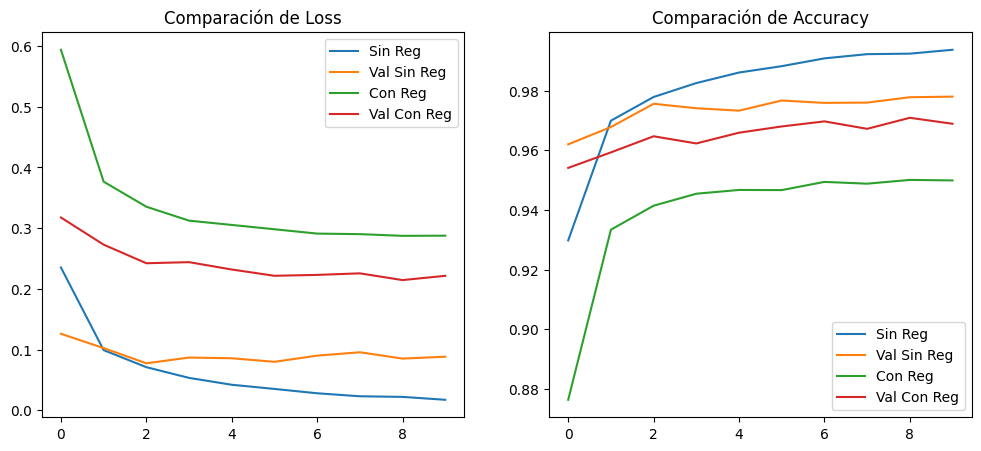

In [5]:
#Graficas
plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.plot(history_sin.history['loss'], label='Sin Reg')
plt.plot(history_sin.history['val_loss'], label='Val Sin Reg')
plt.plot(history_con.history['loss'], label='Con Reg')
plt.plot(history_con.history['val_loss'], label='Val Con Reg')
plt.title('Comparación de Loss')
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(history_sin.history['accuracy'], label='Sin Reg')
plt.plot(history_sin.history['val_accuracy'], label='Val Sin Reg')
plt.plot(history_con.history['accuracy'], label='Con Reg')
plt.plot(history_con.history['val_accuracy'], label='Val Con Reg')
plt.title('Comparación de Accuracy')
plt.legend()

plt.show()

Como conclusión tenemos que al comparar ambos modelos, se observa que el modelo sin regularización tiende a presentar overfitting, evidenciado por una mayor diferencia entre el rendimiento en entrenamiento y validación.
En contraste, el modelo con regularización (Dropout y L2) muestra una mejor generalización, reduciendo la brecha entre entrenamiento y validación, aunque con un ligero aumento en el error de entrenamiento.
Esto demuestra que las técnicas de regularización ayudan a controlar el sobreajuste y mejoran la capacidad del modelo para generalizar a nuevos datos.